# Importación librerías necesarias

In [1]:
import numpy as np
import pandas as pd
import random
from typing import List
import numpy as np
import matplotlib.pyplot as plt
import itertools
import time
from collections import defaultdict
from tqdm import tqdm

# Funciones a emplear en las posteriores simulaciones

### Importación matriz de distancias

In [2]:
def load_mdp_instance(txt_path: str):
    """
    Carga una instancia del Maximum Diversity Problem desde un fichero .txt
    con el formato:
    
        n m
        i j d_ij
        i j d_ij
        ...

    donde solo se almacena la diagonal superior de la matriz de distancias.

    Parámetros
    ----------
    txt_path : str
        Ruta al fichero de texto de la instancia.

    Retorna
    -------
    D : np.ndarray
        Matriz de distancias simétrica de tamaño (n, n).
    n : int
        Número total de elementos.
    m : int
        Número de elementos a seleccionar.
    """
    with open(txt_path, "r", encoding="utf-8") as f:
        # Leemos la primera línea: n y m
        first_line = f.readline().strip().split()
        if len(first_line) != 2:
            raise ValueError("La primera línea del fichero debe contener exactamente dos enteros: n y m.")

        n, m = map(int, first_line)

        # Inicializamos la matriz de distancias
        D = np.zeros((n, n), dtype=float)

        # Leemos las distancias de la diagonal superior
        for line_num, line in enumerate(f, start=2):
            line = line.strip()
            if not line:
                continue  # ignorar líneas vacías

            line_parts = line.split()
            if len(line_parts) != 3:
                raise ValueError(
                    f"Error en la línea {line_num}: se esperaban 3 valores (i, j, d_ij) y se obtuvieron {len(line_parts)}."
                )
            
            # Extraigo índices del par de elementos a comparar
            i, j = map(int, line_parts[:2])
            # Extraigo la distancia entre el par anterior
            dij = float(line_parts[2])
            
            if not (0 <= i < n and 0 <= j < n):
                raise ValueError(
                    f"Error en la línea {line_num}: índices fuera de rango. "
                    f"Se recibió i={i}, j={j}, pero n={n}."
                )

            D[i, j] = dij
            D[j, i] = dij  # simetría

    return D, n, m

### Generación de soluciones

#### Generación aleatoria

In [3]:
def generate_random_solution(N: int, m: int, rng: np.random.Generator | None = None) -> np.ndarray:
    """
    Genera una solución binaria factible aleatoria para el MDP
    como un array de NumPy de longitud N con exactamente m unos.

    Parámetros
    ----------
    N : int
        Número total de elementos.
    m : int
        Número de elementos seleccionados.

    Retorna
    -------
    np.ndarray
        Array binario de longitud N con exactamente m unos.
    """
    if not (0 <= m <= N):
        raise ValueError("Se debe cumplir 0 <= m <= N.")

    if rng is None:
        rng = np.random.default_rng()

    solution = np.zeros(N, dtype=int)
    randomly_selected_positions = rng.choice(N, size=m, replace=False)
    solution[randomly_selected_positions] = 1

    return solution

#### Greedy generation

In [4]:
def generate_greedy_mean_distance_solution(D: np.ndarray, N: int, m: int) -> np.ndarray:
    """
    Genera una solución factible para el MDP de forma constructiva,
    seleccionando sucesivamente los elementos con mayor distancia media
    al resto de elementos.

    Dado que el denominador es constante para todos los elementos,
    se utiliza la suma de cada columna de D en lugar de la media.

    Parámetros
    ----------
    D : np.ndarray
        Matriz de distancias de tamaño (N, N).
    N : int
        Número total de elementos.
    m : int
        Número de elementos a seleccionar.

    Retorna
    -------
    np.ndarray
        Vector binario factible de longitud N con exactamente m unos.
    """
    if D.shape != (N, N):
        raise ValueError("La matriz D debe tener dimensión (N, N).")

    if not (0 <= m <= N):
        raise ValueError("Se debe cumplir 0 <= m <= N.")

    # Suma de distancias de cada elemento al resto
    distance_scores = np.sum(D, axis=0)

    # Índices ordenados de mayor a menor puntuación
    sorted_indices = np.argsort(distance_scores)[::-1]

    # Seleccionamos los m mejores
    selected_indices = sorted_indices[:m]

    # Construimos la solución binaria
    solution = np.zeros(N, dtype=int)
    solution[selected_indices] = 1

    return solution

#### Semi-Greedy generation

In [5]:
def generate_stepwise_mixed_solution(
    D: np.ndarray,
    N: int,
    m: int,
    n_steps: int,
    rng: np.random.Generator | None = None
) -> np.ndarray:
    """
    Genera una solución factible de longitud N con exactamente m unos
    siguiendo un esquema intermedio random-greedy por etapas.

    En total se realizan 2*n_steps fases:
      - fase 1: añadir elementos aleatoriamente
      - fase 2: añadir elementos greedy respecto a los ya seleccionados
      - fase 3: aleatoria
      - fase 4: greedy
      - ...
    
    Cada fase añade aproximadamente m / (2*n_steps) elementos.
    La distribución exacta se ajusta para que al final se seleccionen
    exactamente m elementos.

    En las fases greedy, se añaden los elementos no seleccionados cuya
    distancia media a los ya presentes en la solución parcial es máxima.

    Parámetros
    ----------
    D : np.ndarray
        Matriz de distancias de tamaño (N, N).
    N : int
        Número total de elementos.
    m : int
        Número de elementos que debe contener la solución.
    n_steps : int
        Número de etapas random-greedy.
    rng : np.random.Generator | None
        Generador aleatorio.
    stats : dict | None
        Diccionario opcional donde acumular métricas del operador.
    stats : dict | None
        Diccionario opcional donde acumular métricas del operador.
    stats : dict | None
        Diccionario opcional donde acumular métricas del operador.

    Retorna
    -------
    np.ndarray
        Vector binario factible de longitud N con exactamente m unos.
    """
    if rng is None:
        rng = np.random.default_rng()

    if D.shape != (N, N):
        raise ValueError("La matriz D debe tener dimensión (N, N).")

    if not (0 <= m <= N):
        raise ValueError("Se debe cumplir 0 <= m <= N.")

    if n_steps <= 0:
        raise ValueError("n_steps debe ser un entero positivo.")

    if m == 0:
        return np.zeros(N, dtype=int)

    num_phases = 2 * n_steps

    # Repartimos exactamente m selecciones entre las 2*n_steps fases
    base = m // num_phases
    remainder = m % num_phases

    phase_sizes = np.full(num_phases, base, dtype=int)
    phase_sizes[:remainder] += 1

    selected = []
    selected_set = set()
    remaining = set(range(N))

    for phase_idx, phase_size in enumerate(phase_sizes):
        if phase_size == 0:
            continue

        # Fases pares (0,2,4,...) -> random
        if phase_idx % 2 == 0:
            chosen = rng.choice(list(remaining), size=phase_size, replace=False)
            chosen = chosen.tolist()

        # Fases impares (1,3,5,...) -> greedy respecto a los ya seleccionados
        else:
            # Si por algún motivo aún no hay seleccionados, hacemos esta fase aleatoria
            if len(selected) == 0:
                chosen = rng.choice(list(remaining), size=phase_size, replace=False)
                chosen = chosen.tolist()
            else:
                candidates = np.array(list(remaining), dtype=int)

                # Distancia media de cada candidato a los ya seleccionados
                mean_distances = np.mean(D[np.ix_(candidates, selected)], axis=1)

                # Elegimos los phase_size candidatos con mayor distancia media
                top_idx = np.argsort(mean_distances)[::-1][:phase_size]
                chosen = candidates[top_idx].tolist()

        for elem in chosen:
            selected.append(elem)
            selected_set.add(elem)
            remaining.remove(elem)

    solution = np.zeros(N, dtype=int)
    solution[selected] = 1

    return solution

### Generación de poblaciones

In [6]:
import numpy as np


def generate_population(
    N: int,
    m: int,
    p: int,
    method: str = "random",
    D: np.ndarray | None = None,
    n_steps: int = 1,
    rng: np.random.Generator | None = None
) -> np.ndarray:
    """
    Genera una población inicial de tamaño p para el MDP.

    Puede generarse de tres formas:
    - 'random': soluciones factibles aleatorias.
    - 'greedy': soluciones factibles construidas con la heurística voraz
      basada en la mayor distancia media global.
    - 'randomized_greedy': soluciones construidas mediante un esquema
      intermedio random-greedy por etapas.

    Parámetros
    ----------
    N : int
        Número total de elementos.
    m : int
        Número de elementos seleccionados en cada solución.
    p : int
        Tamaño de la población.
    method : str, opcional
        Método de generación de la población:
        'random', 'greedy' o 'randomized_greedy'.
    D : np.ndarray | None, opcional
        Matriz de distancias de tamaño (N, N). Necesaria si method es
        'greedy' o 'randomized_greedy'.
    n_steps : int, opcional
        Número de etapas del método 'randomized_greedy'.
    rng : np.random.Generator | None, opcional
        Generador aleatorio.

    Retorna
    -------
    np.ndarray
        Matriz de tamaño (p, N), donde cada fila es una solución factible.
    """
    if rng is None:
        rng = np.random.default_rng()

    if p <= 0:
        raise ValueError("El tamaño de la población p debe ser positivo.")

    if not (0 <= m <= N):
        raise ValueError("Se debe cumplir 0 <= m <= N.")

    if method not in {"random", "greedy", "randomized_greedy"}:
        raise ValueError(
            "method debe ser 'random', 'greedy' o 'randomized_greedy'."
        )

    if method in {"greedy", "randomized_greedy"}:
        if D is None:
            raise ValueError(
                "Si method es 'greedy' o 'randomized_greedy', es necesario proporcionar la matriz D."
            )
        if D.shape != (N, N):
            raise ValueError("La matriz D debe tener dimensión (N, N).")

    if method == "randomized_greedy" and n_steps <= 0:
        raise ValueError("n_steps debe ser un entero positivo.")

    population = np.zeros((p, N), dtype=int)

    for i in range(p):
        if method == "random":
            population[i] = generate_random_solution(N, m, rng=rng)

        elif method == "greedy":
            population[i] = generate_greedy_mean_distance_solution(D, N, m)

        elif method == "randomized_greedy":
            population[i] = generate_stepwise_mixed_solution(
                D=D,
                N=N,
                m=m,
                n_steps=n_steps,
                rng=rng
            )

    return population

### Cómputo de fitness

In [7]:
def compute_fitness(solution: np.ndarray, D: np.ndarray) -> float:
    """
    Calcula el fitness de una solución factible del MDP.

    El fitness se define como la suma de las distancias entre todos
    los pares de elementos seleccionados.

    Parámetros
    ----------
    solution : np.ndarray
        Array binario factible de longitud N.
    D : np.ndarray
        Matriz de distancias de tamaño (N, N).

    Retorna
    -------
    float
        Valor de la función objetivo.
    """
    if solution.ndim != 1:
        raise ValueError("La solución debe ser un array unidimensional.")

    N = solution.shape[0]

    if D.shape != (N, N):
        raise ValueError("La matriz D debe tener dimensión (N, N).")

    return float(0.5 * solution @ D @ solution)

### Selección de padres 

#### Greedy

In [8]:
def select_top_k_from_random_fraction(
    population: np.ndarray,
    fitness: np.ndarray,
    z_percent: float,
    k: int,
    rng: np.random.Generator | None = None,
    return_indices: bool = False
):
    """
    Selecciona aleatoriamente un z% de la población y devuelve los k individuos
    con mayor fitness dentro de ese subconjunto.

    Parámetros
    ----------
    population : np.ndarray
        Matriz de tamaño (p, N), donde cada fila es un individuo.
    fitness : np.ndarray
        Vector de tamaño (p,) con el fitness de cada individuo.
    z_percent : float
        Porcentaje de población a muestrear, en (0, 100].
    k : int
        Número de padres a seleccionar.
    rng : np.random.Generator | None
        Generador aleatorio.
    return_indices : bool
        Si True, devuelve también los índices originales en la población.

    Retorna
    -------
    parents : np.ndarray
        Matriz de tamaño (k, N) con los padres seleccionados.
    indices : np.ndarray, opcional
        Índices originales de los padres seleccionados en la población.
    """
    if rng is None:
        rng = np.random.default_rng()

    if population.ndim != 2:
        raise ValueError("population debe ser una matriz de tamaño (p, N).")

    p = population.shape[0]

    if fitness.shape != (p,):
        raise ValueError("fitness debe tener tamaño (p,).")

    if not (0 < z_percent <= 100):
        raise ValueError("z_percent debe estar en el intervalo (0, 100].")

    if not (1 <= k <= p):
        raise ValueError("k debe cumplir 1 <= k <= tamaño de la población.")

    sample_size = max(1, int(np.ceil((z_percent / 100.0) * p)))

    if k > sample_size:
        raise ValueError("k no puede ser mayor que el tamaño del subconjunto aleatorio seleccionado.")

    # Computo aleatoriamente índices de los individuos a comparar
    sampled_indices = rng.choice(p, size=sample_size, replace=False)
    sampled_fitness = fitness[sampled_indices]

    # Índices locales de los k mejores, ordenados de mayor a menor fitness
    top_local = np.argsort(sampled_fitness)[-k:][::-1]
    selected_indices = sampled_indices[top_local]

    parents = population[selected_indices].copy()

    if return_indices:
        return parents, selected_indices

    return parents

#### Simmulated Annealing

In [9]:
def select_k_from_random_fraction_sa(
    population: np.ndarray,
    fitness: np.ndarray,
    z_percent: float,
    k: int,
    temperature: float,
    rng: np.random.Generator | None = None,
    return_indices: bool = False
):
    """
    Selecciona aleatoriamente un z% de la población y, dentro de ese subconjunto,
    elige k padres siguiendo una estrategia probabilística inspirada en
    simulated annealing.

    En lugar de escoger siempre los k mejores, cada individuo del subconjunto
    recibe una probabilidad proporcional a:

        exp((f_i - f_max) / T)

    donde:
    - f_i es su fitness,
    - f_max es el mayor fitness del subconjunto,
    - T es la temperatura.

    Cuanto mayor es T, más uniforme es la selección.
    Cuanto menor es T, más se favorece a los individuos con mayor fitness.

    Parámetros
    ----------
    population : np.ndarray
        Matriz de tamaño (p, N), donde cada fila es un individuo.
    fitness : np.ndarray
        Vector de tamaño (p,) con el fitness de cada individuo.
    z_percent : float
        Porcentaje de población a muestrear, en (0, 100].
    k : int
        Número de padres a seleccionar.
    temperature : float
        Temperatura del esquema de selección. Debe ser positiva.
    rng : np.random.Generator | None
        Generador aleatorio.
    return_indices : bool
        Si True, devuelve también los índices originales de los padres
        seleccionados en la población.

    Retorna
    -------
    parents : np.ndarray
        Matriz de tamaño (k, N) con los padres seleccionados.
    indices : np.ndarray, opcional
        Índices originales de los padres seleccionados.
    """
    if rng is None:
        rng = np.random.default_rng()

    if population.ndim != 2:
        raise ValueError("population debe ser una matriz de tamaño (p, N).")

    p = population.shape[0]

    if fitness.shape != (p,):
        raise ValueError("fitness debe tener tamaño (p,).")

    if not (0 < z_percent <= 100):
        raise ValueError("z_percent debe estar en el intervalo (0, 100].")

    if not (1 <= k <= p):
        raise ValueError("k debe cumplir 1 <= k <= tamaño de la población.")

    if temperature <= 0:
        raise ValueError("temperature debe ser positiva.")

    sample_size = max(1, int(np.ceil((z_percent / 100.0) * p)))

    if k > sample_size:
        raise ValueError(
            "k no puede ser mayor que el tamaño del subconjunto aleatorio seleccionado."
        )

    # 1. Muestreo aleatorio del subconjunto
    sampled_indices = rng.choice(p, size=sample_size, replace=False)
    sampled_fitness = fitness[sampled_indices]

    # 2. Pesos tipo simulated annealing
    f_max = np.max(sampled_fitness)
    shifted = sampled_fitness - f_max
    weights = np.exp(shifted / temperature)

    # Normalización a probabilidades
    prob = weights / np.sum(weights)

    # 3. Selección sin reemplazamiento según dichas probabilidades
    selected_local = rng.choice(sample_size, size=k, replace=False, p=prob)
    selected_indices = sampled_indices[selected_local]

    parents = population[selected_indices].copy()

    if return_indices:
        return parents, selected_indices

    return parents

### Mutaciones

#### Intercambio aleatorio 0-1

In [10]:
def mutate_swap_bits(
    solution: np.ndarray,
    n_swaps: int,
    rng: np.random.Generator | None = None,
    stats: dict | None = None
) -> np.ndarray:
    """
    Realiza una mutación intercambiando aleatoriamente hasta max_swaps pares
    de posiciones con valores distintos (1 y 0).

    La factibilidad se preserva automáticamente.

    Parámetros
    ----------
    solution : np.ndarray
        Vector binario factible de longitud N.
    max_swaps : int
        Número máximo de intercambios 1<->0.
    rng : np.random.Generator | None
        Generador aleatorio.

    Retorna
    -------
    mutated : np.ndarray
        Solución mutada.
    """
    if rng is None:
        rng = np.random.default_rng()

    if solution.ndim != 1:
        raise ValueError("solution debe ser un vector unidimensional.")

    if n_swaps < 1:
        raise ValueError("n_swaps debe ser al menos 1.")

    mutated = solution.copy()

    # Extraigo índices de 1s y 0s
    ones = np.where(mutated == 1)[0]# -> m
    zeros = np.where(mutated == 0)[0]# -> N-m

    if n_swaps > len(ones):
        raise ValueError("n_swaps debe ser menor o igual que m (número de 1s en solución factible).")

    chosen_ones = rng.choice(ones, size=n_swaps, replace=False)
    chosen_zeros = rng.choice(zeros, size=n_swaps, replace=False)

    mutated[chosen_ones] = 0
    mutated[chosen_zeros] = 1

    if stats is not None:
        stats["mutate_swap_bits_success"] = stats.get("mutate_swap_bits_success", 0) + 1

    return mutated

#### Intercambio aleatorio de bloques

In [11]:
def mutate_swap_blocks(
    solution: np.ndarray,
    block_size: int,
    rng: np.random.Generator | None = None,
    max_tries: int = 20,
    stats: dict | None = None
) -> np.ndarray:
    """
    Intercambia aleatoriamente dos bloques disjuntos de tamaño block_size
    dentro de la misma solución, siempre que sean distintos.

    La factibilidad se preserva automáticamente.

    Parámetros
    ----------
    solution : np.ndarray
        Vector binario factible de longitud N.
    block_size : int
        Tamaño de los bloques a intercambiar.
    rng : np.random.Generator | None
        Generador aleatorio.
    max_tries : int
        Número máximo de intentos para encontrar dos bloques distintos.
    stats : dict | None
        Diccionario opcional donde acumular métricas del operador.

    Retorna
    -------
    mutated : np.ndarray
        Solución mutada.
    """
    if rng is None:
        rng = np.random.default_rng()

    if solution.ndim != 1:
        raise ValueError("solution debe ser un vector unidimensional.")

    N = solution.shape[0]

    if not (1 <= block_size <= N // 2):
        raise ValueError("block_size debe cumplir 1 <= block_size <= N//2.")

    mutated = solution.copy()

    for _ in range(max_tries):
        start1 = rng.integers(0, N - block_size + 1)
        start2 = rng.integers(0, N - block_size + 1)

        # Forzamos bloques disjuntos
        if not (start1 + block_size <= start2 or start2 + block_size <= start1):
            continue # salto directamente a la siguiente iteración

        block1 = mutated[start1:start1 + block_size].copy()
        block2 = mutated[start2:start2 + block_size].copy()

        if np.array_equal(block1, block2):
            continue # salto directamente a la siguiente iteración

        mutated[start1:start1 + block_size] = block2
        mutated[start2:start2 + block_size] = block1

        if stats is not None:
            stats["mutate_swap_blocks_success"] = stats.get("mutate_swap_blocks_success", 0) + 1

        return mutated

    if stats is not None:
        stats["mutate_swap_blocks_noop"] = stats.get("mutate_swap_blocks_noop", 0) + 1

    return mutated

### Cruce

#### Intercambio 0s/1s

In [12]:
def crossover_swap_differences(
    parent1: np.ndarray,
    parent2: np.ndarray,
    max_exchanges: int,
    rng: np.random.Generator | None = None,
    stats: dict | None = None
) -> tuple[np.ndarray, np.ndarray]:
    """
    Cruce entre dos padres factibles intercambiando hasta max_exchanges
    posiciones discordantes de tipo (1,0) y (0,1).

    Devuelve dos hijos factibles.

    Parámetros
    ----------
    parent1, parent2 : np.ndarray
        Vectores binarios factibles de igual longitud.
    max_exchanges : int
        Número máximo de intercambios.
    rng : np.random.Generator | None
        Generador aleatorio.

    Retorna
    -------
    child1, child2 : tuple[np.ndarray, np.ndarray]
        Dos hijos factibles.
    """
    if rng is None:
        rng = np.random.default_rng()

    if parent1.ndim != 1 or parent2.ndim != 1:
        raise ValueError("Los padres deben ser vectores unidimensionales.")

    if parent1.shape != parent2.shape:
        raise ValueError("Los padres deben tener la misma longitud.")

    if np.sum(parent1) != np.sum(parent2):
        raise ValueError("Los padres deben tener la misma cardinalidad para preservar factibilidad.")

    if max_exchanges < 1:
        raise ValueError("max_exchanges debe ser al menos 1.")

    child1 = parent1.copy()
    child2 = parent2.copy()
    
    # Extract where par1=1 and par2=0
    idx_10 = np.where((parent1 == 1) & (parent2 == 0))[0]
    # Extract where par1=0 and par2=1
    idx_01 = np.where((parent1 == 0) & (parent2 == 1))[0]

    # Limito el número de intercambios al máximo posible
    max_possible = min(max_exchanges, len(idx_10), len(idx_01))
    if max_possible == 0:
        if stats is not None:
            stats["crossover_swap_diff_noop"] = stats.get("crossover_swap_diff_noop", 0) + 1
        return child1, child2
    if max_possible != max_exchanges:
        if stats is not None:
            stats["crossover_swap_diff_limited"] = stats.get("crossover_swap_diff_limited", 0) + 1

    chosen_10 = rng.choice(idx_10, size=max_possible, replace=False)
    chosen_01 = rng.choice(idx_01, size=max_possible, replace=False)

    # En child1: las de chosen_10 pasan a 0 y las de chosen_01 pasan a 1
    child1[chosen_10] = 0
    child1[chosen_01] = 1

    # En child2: operación complementaria
    child2[chosen_10] = 1
    child2[chosen_01] = 0

    if stats is not None:
        stats["crossover_swap_diff_success"] = stats.get("crossover_swap_diff_success", 0) + 1

    return child1, child2

#### Suma soluciones + reparación en 1s

In [13]:
def crossover_sum_repair(
    parent1: np.ndarray,
    parent2: np.ndarray,
    rng: np.random.Generator | None = None
) -> np.ndarray:
    """
    Cruce entre dos padres basado en la suma de ambos.

    - Se suman los padres: vector con valores 0,1,2.
    - Las posiciones con valor 2 pasan a 1 en el hijo.
    - Las posiciones con valor 1 son candidatas a completar la solución.
    - Se añaden aleatoriamente los unos que falten hasta recuperar la factibilidad.

    Devuelve un único hijo factible.

    Parámetros
    ----------
    parent1, parent2 : np.ndarray
        Vectores binarios factibles de igual longitud.
    rng : np.random.Generator | None
        Generador aleatorio.

    Retorna
    -------
    child : np.ndarray
        Hijo factible.
    """
    if rng is None:
        rng = np.random.default_rng()

    if parent1.ndim != 1 or parent2.ndim != 1:
        raise ValueError("Los padres deben ser vectores unidimensionales.")

    if parent1.shape != parent2.shape:
        raise ValueError("Los padres deben tener la misma longitud.")

    m1 = int(np.sum(parent1))
    m2 = int(np.sum(parent2))

    if m1 != m2:
        raise ValueError("Los padres deben tener la misma cardinalidad.")

    m = m1

    summed = parent1 + parent2

    child = np.zeros_like(parent1)

    # Los 2 se fijan a 1 para reforzar atributos comunes
    common_idx = np.where(summed == 2)[0]
    child[common_idx] = 1
    
    already_selected = len(common_idx)
    missing = m - already_selected

    if missing < 0:
        raise ValueError("Se ha generado una cardinalidad inválida; esto no debería ocurrir.")

    if missing == 0:
        return child

    candidate_idx = np.where(summed == 1)[0]

    if len(candidate_idx) < missing:
        raise ValueError("No hay suficientes posiciones candidatas para reparar el hijo.")

    chosen = rng.choice(candidate_idx, size=missing, replace=False)
    child[chosen] = 1

    return child

### Test factibilidad

In [14]:
def is_feasible(solution: np.ndarray, m: int) -> bool:
    """
    Comprueba si una solución es binaria y tiene exactamente m unos.
    """
    if solution.ndim != 1:
        return False

    if not np.all((solution == 0) | (solution == 1)):
        return False

    return int(np.sum(solution)) == m

### Función de testeo

In [15]:
def test_genetic_mdp(
    D: np.ndarray,
    N: int,
    m: int,
    num_generations: int,
    population_size: int,
    init_method: str = "random",             # "random", "greedy", "randomized_greedy"
    n_steps: int = 1,                        # solo para randomized_greedy
    p_s: float = 20.0,                       # % de población muestreada para torneo
    p_p: float = 10.0,                       # % de población total seleccionado como padres
    p_c: float = 50.0,                       # % de padres usados para cruce
    substitution: str = "worst",             # "random" o "worst"
    parent_selection_method: str = "greedy", # "greedy" o "sa"
    parent_selection_kwargs: dict | None = None,
    crossover_operators: dict | None = None, # {"sum_repair": 0.5, "swap_differences": 0.5}
    mutation_operators: dict | None = None,  # {"swap_bits": 0.5, "swap_blocks": 0.5}
    print_every: int | None = 1,
    hamming_every: int = 10,
    restart_method: str | None = None,       # None, "random", "fitness_weighted"
    restart_percent: float = 0.0,            # porcentaje de población a reiniciar
    restart_every: int = 0,                  # generaciones entre reinicios; 0 desactiva
    unique_offspring: bool = False,
    rng: np.random.Generator | None = None,
):
    """
    Ejecuta una fase de testeo del algoritmo genético para el MDP.

    En cada generación:
    1. Se toma aleatoriamente un subconjunto del p_s% de la población.
    2. Dentro de él se seleccionan los padres usando el método indicado
       en parent_selection_method.
    3. Un p_c% de esos padres se reserva para cruce y el resto para mutación.
    4. El operador concreto de cruce y de mutación se elige aleatoriamente
       según los diccionarios de probabilidades proporcionados.
    5. Los hijos sustituyen a parte de la población según 'substitution'.

    Además, se mide:
    - tiempo de inicialización de la población,
    - tiempo total de evolución.

    Retorna
    -------
    best_solution : np.ndarray
    best_fitness : float
    population : np.ndarray
    fitness : np.ndarray
    history : dict
    config : dict
    timing : dict
    """
    if rng is None:
        rng = np.random.default_rng()

    if parent_selection_kwargs is None:
        parent_selection_kwargs = {}

    # ------------------------------------------------------------
    # Diccionarios por defecto
    # ------------------------------------------------------------
    if crossover_operators is None:
        crossover_operators = {
            "sum_repair": 0.5,
            "swap_differences": 0.5,
        }

    if mutation_operators is None:
        mutation_operators = {
            "swap_bits": 0.5,
            "swap_blocks": 0.5,
        }

    # ------------------------------------------------------------
    # Operadores disponibles
    # ------------------------------------------------------------
    crossover_fn_map = {
        "sum_repair": crossover_sum_repair,
        "swap_differences": crossover_swap_differences,
    }

    mutation_fn_map = {
        "swap_bits": mutate_swap_bits,
        "swap_blocks": mutate_swap_blocks,
    }

    # ------------------------------------------------------------
    # Validaciones generales
    # ------------------------------------------------------------
    if D.shape != (N, N):
        raise ValueError("La matriz D debe tener dimensión (N, N).")

    if population_size <= 0:
        raise ValueError("population_size debe ser positivo.")

    if num_generations < 0:
        raise ValueError("num_generations no puede ser negativo.")

    if init_method not in {"random", "greedy", "randomized_greedy"}:
        raise ValueError("init_method debe ser 'random', 'greedy' o 'randomized_greedy'.")

    if substitution not in {"random", "worst"}:
        raise ValueError("substitution debe ser 'random' o 'worst'.")

    if parent_selection_method not in {"greedy", "sa"}:
        raise ValueError("parent_selection_method debe ser 'greedy' o 'sa'.")

    if not (0 < p_p < p_s <= 100):
        raise ValueError("Debe cumplirse 0 < p_p < p_s <= 100.")

    if not (0 <= p_c <= 100):
        raise ValueError("p_c debe estar en [0, 100].")

    if print_every is not None:
        if not isinstance(print_every, int) or print_every <= 0:
            raise ValueError("print_every debe ser un entero positivo o None.")

    if hamming_every is not None and hamming_every < 0:
        raise ValueError("hamming_every debe ser >= 0 o None.")

    if restart_method not in {None, "random", "fitness_weighted"}:
        raise ValueError("restart_method debe ser None, 'random' o 'fitness_weighted'.")

    if restart_method is not None:
        if not (0 < restart_percent <= 100):
            raise ValueError("Si se activa restart_method, restart_percent debe estar en (0, 100].")
        if restart_every <= 0:
            raise ValueError("Si se activa restart_method, restart_every debe ser un entero positivo.")
    if not isinstance(unique_offspring, bool):
        raise ValueError("unique_offspring debe ser booleano.")

    # ------------------------------------------------------------
    # Validación de probabilidades de operadores
    # ------------------------------------------------------------
    def validate_operator_probs(op_dict: dict, valid_names: dict, dict_name: str):
        if not isinstance(op_dict, dict) or len(op_dict) == 0:
            raise ValueError(f"{dict_name} debe ser un diccionario no vacío.")

        for name, prob in op_dict.items():
            if name not in valid_names:
                raise ValueError(
                    f"Operador '{name}' no reconocido en {dict_name}. "
                    f"Válidos: {list(valid_names.keys())}"
                )
            if prob < 0:
                raise ValueError(f"La probabilidad de '{name}' en {dict_name} no puede ser negativa.")

        total = sum(op_dict.values())
        if not np.isclose(total, 1.0):
            raise ValueError(f"Las probabilidades de {dict_name} deben sumar 1. Suman {total}.")

    validate_operator_probs(crossover_operators, crossover_fn_map, "crossover_operators")
    validate_operator_probs(mutation_operators, mutation_fn_map, "mutation_operators")

    # ------------------------------------------------------------
    # Tamaños derivados
    # ------------------------------------------------------------
    sample_size = max(1, int(np.ceil(population_size * p_s / 100.0)))
    num_parents = max(1, int(np.ceil(population_size * p_p / 100.0)))

    if sample_size < num_parents:
        raise ValueError(
            f"Con population_size={population_size}, p_s={p_s} y p_p={p_p}, "
            f"solo se muestrean {sample_size} individuos pero se quieren seleccionar {num_parents} padres."
        )

    num_cross_parents = int(np.floor(num_parents * p_c / 100.0))
    num_mut_parents = num_parents - num_cross_parents

    if 0 < num_cross_parents < 2:
        num_cross_parents = 0
        num_mut_parents = num_parents

    if num_cross_parents % 2 == 1:
        num_cross_parents -= 1
        num_mut_parents += 1

    # ------------------------------------------------------------
    # Población inicial + tiempo
    # ------------------------------------------------------------
    t0_init = time.perf_counter()

    population = generate_population(
        N=N,
        m=m,
        p=population_size,
        method=init_method,
        D=D,
        n_steps=n_steps,
        rng=rng
    )

    fitness = np.array([compute_fitness(ind, D) for ind in population], dtype=float)

    t1_init = time.perf_counter()
    initialization_time = t1_init - t0_init

    initial_best_idx = np.argmax(fitness)
    initial_best_fitness = float(fitness[initial_best_idx])

    best_solution = population[initial_best_idx].copy()
    best_fitness = initial_best_fitness

    history = {
        "generation": [0],
        "best_generation_fitness": [initial_best_fitness],
        "best_global_fitness": [initial_best_fitness],
        "mean_fitness": [float(np.mean(fitness))],
        "operator_stats_delta": [dict()],
        "mean_pairwise_hamming": [],
    }

    operator_stats = defaultdict(int)

    num_restart = 0
    if restart_method is not None:
        num_restart = max(1, int(np.ceil(population_size * restart_percent / 100.0)))

    if print_every is not None:
        print(
            f"Generation 0 | "
            f"Initial best = {initial_best_fitness:.4f} | "
            f"Best in population = {initial_best_fitness:.4f} | "
            f"Current global best = {best_fitness:.4f} | "
            f"Mean fitness = {np.mean(fitness):.4f}"
        )

    # ------------------------------------------------------------
    # Utilidad para elegir operador según probabilidades
    # ------------------------------------------------------------
    def choose_operator(op_dict: dict):
        names = list(op_dict.keys())
        probs = np.array(list(op_dict.values()), dtype=float)
        idx = rng.choice(len(names), p=probs)
        return names[idx]

    def compute_mean_pairwise_hamming(pop: np.ndarray) -> float:
        # pop shape: (population_size, N) with binary entries
        if pop.ndim != 2 or pop.shape[0] < 2:
            return 0.0
        ones = np.sum(pop, axis=1)
        overlap = pop @ pop.T
        dist_matrix = ones[:, None] + ones[None, :] - 2 * overlap
        triu_idx = np.triu_indices_from(dist_matrix, k=1)
        if triu_idx[0].size == 0:
            return 0.0
        return float(np.mean(dist_matrix[triu_idx]))

    def restart_population_random(pop: np.ndarray, fit: np.ndarray, k: int):
        if k <= 0:
            return
        idx = rng.choice(pop.shape[0], size=k, replace=False)
        for i in idx:
            pop[i] = generate_random_solution(N, m, rng=rng)
            fit[i] = compute_fitness(pop[i], D)

    def restart_population_fitness_weighted(pop: np.ndarray, fit: np.ndarray, k: int):
        if k <= 0:
            return
        min_f = np.min(fit)
        scores = 1.0 / (fit - min_f + 1e-9)
        probs = scores / np.sum(scores)
        idx = rng.choice(pop.shape[0], size=k, replace=False, p=probs)
        for i in idx:
            pop[i] = generate_random_solution(N, m, rng=rng)
            fit[i] = compute_fitness(pop[i], D)

    # Métrica de generación 0 (según hamming_every)
    if hamming_every is not None and hamming_every > 0:
        history["mean_pairwise_hamming"].append(compute_mean_pairwise_hamming(population))

    # ------------------------------------------------------------
    # Evolución + tiempo
    # ------------------------------------------------------------
    t0_evol = time.perf_counter()

    for gen in range(1, num_generations + 1):

        prev_op_stats = dict(operator_stats)

        # --------------------------------------------------------
        # 1) Selección de padres
        # --------------------------------------------------------
        if parent_selection_method == "greedy":
            parents = select_top_k_from_random_fraction(
                population=population,
                fitness=fitness,
                z_percent=p_s,
                k=num_parents,
                rng=rng,
                return_indices=False
            )

        elif parent_selection_method == "sa":
            temperature = parent_selection_kwargs.get("temperature", None)
            if temperature is None:
                raise ValueError(
                    "Si parent_selection_method='sa', parent_selection_kwargs debe incluir 'temperature'."
                )

            parents = select_k_from_random_fraction_sa(
                population=population,
                fitness=fitness,
                z_percent=p_s,
                k=num_parents,
                temperature=temperature,
                rng=rng,
                return_indices=False
            )

        # --------------------------------------------------------
        # 2) Separación cruce / mutación
        # --------------------------------------------------------
        perm = rng.permutation(num_parents)
        cross_parent_ids = perm[:num_cross_parents]
        mut_parent_ids = perm[num_cross_parents:]

        crossover_parents = parents[cross_parent_ids]
        mutation_parents = parents[mut_parent_ids]

        children = []

        # --------------------------------------------------------
        # 3) Hijos por cruce
        # --------------------------------------------------------
        if num_cross_parents >= 2:
            rng.shuffle(crossover_parents)

            for i in range(0, num_cross_parents, 2):
                p1 = crossover_parents[i]
                p2 = crossover_parents[i + 1]

                cross_name = choose_operator(crossover_operators)
                cross_fn = crossover_fn_map[cross_name]

                if cross_name == "sum_repair":
                    child = cross_fn(p1, p2, rng=rng)
                    children.append(child)

                elif cross_name == "swap_differences":
                    child1, child2 = cross_fn(p1, p2,  max_exchanges=2, rng=rng, stats=operator_stats)
                    children.append(child1)
                    children.append(child2)

        # --------------------------------------------------------
        # 4) Hijos por mutación
        # --------------------------------------------------------
        for parent in mutation_parents:
            mut_name = choose_operator(mutation_operators)
            mut_fn = mutation_fn_map[mut_name]

            if mut_name == "swap_bits":
                child = mut_fn(parent.copy(), n_swaps=2, rng=rng, stats=operator_stats)

            elif mut_name == "swap_blocks":
                block_size = max(1, min(3, N // 4))
                if block_size > N // 2:
                    block_size = max(1, N // 2)
                child = mut_fn(parent.copy(), block_size=block_size, rng=rng, stats=operator_stats)

            children.append(child)

        if len(children) == 0:
            gen_best_fitness = float(np.max(fitness))
            gen_delta = {k: operator_stats[k] - prev_op_stats.get(k, 0) for k in operator_stats}
            if hamming_every is not None and hamming_every > 0 and gen % hamming_every == 0:
                history["mean_pairwise_hamming"].append(compute_mean_pairwise_hamming(population))
            history["generation"].append(gen)
            history["best_generation_fitness"].append(gen_best_fitness)
            history["best_global_fitness"].append(best_fitness)
            history["mean_fitness"].append(float(np.mean(fitness)))
            history["operator_stats_delta"].append(gen_delta)

            if print_every is not None and gen % print_every == 0:
                print(
                    f"Generation {gen} | "
                    f"Initial best = {initial_best_fitness:.4f} | "
                    f"Best in population = {gen_best_fitness:.4f} | "
                    f"Current global best = {best_fitness:.4f} | "
                    f"Mean fitness = {np.mean(fitness):.4f}"
                )
            continue

        children = np.array(children, dtype=int)
        children_fitness = np.array([compute_fitness(ind, D) for ind in children], dtype=float)
        if unique_offspring:
            existing = {tuple(ind.tolist()) for ind in population}
            keep_idx = []
            for idx_child, child in enumerate(children):
                tup = tuple(child.tolist())
                if tup in existing:
                    continue
                keep_idx.append(idx_child)
                existing.add(tup)
            if len(keep_idx) == 0:
                gen_best_fitness = float(np.max(fitness))
                gen_delta = {k: operator_stats[k] - prev_op_stats.get(k, 0) for k in operator_stats}
                if hamming_every is not None and hamming_every > 0 and gen % hamming_every == 0:
                    history["mean_pairwise_hamming"].append(compute_mean_pairwise_hamming(population))
                history["generation"].append(gen)
                history["best_generation_fitness"].append(gen_best_fitness)
                history["best_global_fitness"].append(best_fitness)
                history["mean_fitness"].append(float(np.mean(fitness)))
                history["operator_stats_delta"].append(gen_delta)
                if print_every is not None and gen % print_every == 0:
                    print(
                        f"Generation {gen} | "
                        f"Initial best = {initial_best_fitness:.4f} | "
                        f"Best in population = {gen_best_fitness:.4f} | "
                        f"Current global best = {best_fitness:.4f} | "
                        f"Mean fitness = {np.mean(fitness):.4f}"
                    )
                continue
            children = children[keep_idx]
            children_fitness = children_fitness[keep_idx]

        num_children = len(children)

        # --------------------------------------------------------
        # 5) Sustitución
        # --------------------------------------------------------
        effective_size = min(num_children, population_size)

        if substitution == "random":
            replace_idx = rng.choice(population_size, size=effective_size, replace=False)
        else:  # worst
            replace_idx = np.argsort(fitness)[:effective_size]

        population[replace_idx] = children[:effective_size]
        fitness[replace_idx] = children_fitness[:effective_size]

        # --------------------------------------------------------
        # 5b) Reinicio opcional
        # --------------------------------------------------------
        if restart_method is not None and restart_every > 0 and gen % restart_every == 0:
            if restart_method == "random":
                restart_population_random(population, fitness, num_restart)
            else:  # fitness_weighted
                restart_population_fitness_weighted(population, fitness, num_restart)

        # --------------------------------------------------------
        # 6) Métricas
        # --------------------------------------------------------
        gen_best_idx = np.argmax(fitness)
        gen_best_fitness = float(fitness[gen_best_idx])

        if gen_best_fitness > best_fitness:
            best_fitness = gen_best_fitness
            best_solution = population[gen_best_idx].copy()

        gen_delta = {k: operator_stats[k] - prev_op_stats.get(k, 0) for k in operator_stats}

        if hamming_every is not None and hamming_every > 0 and gen % hamming_every == 0:
            history["mean_pairwise_hamming"].append(compute_mean_pairwise_hamming(population))

        history["generation"].append(gen)
        history["best_generation_fitness"].append(gen_best_fitness)
        history["best_global_fitness"].append(best_fitness)
        history["mean_fitness"].append(float(np.mean(fitness)))
        history["operator_stats_delta"].append(gen_delta)

        if print_every is not None and gen % print_every == 0:
            print(
                f"Generation {gen} | "
                f"Initial best = {initial_best_fitness:.4f} | "
                f"Best in population = {gen_best_fitness:.4f} | "
                f"Current global best = {best_fitness:.4f} | "
                f"Mean fitness = {np.mean(fitness):.4f}"
            )

    t1_evol = time.perf_counter()
    evolution_time = t1_evol - t0_evol

    # ------------------------------------------------------------
    # Configuración y tiempos
    # ------------------------------------------------------------
    config = {
        "N": N,
        "m": m,
        "num_generations": num_generations,
        "population_size": population_size,
        "init_method": init_method,
        "n_steps": n_steps,
        "p_s": p_s,
        "p_p": p_p,
        "p_c": p_c,
        "substitution": substitution,
        "parent_selection_method": parent_selection_method,
        "parent_selection_kwargs": parent_selection_kwargs,
        "crossover_operators": crossover_operators,
        "mutation_operators": mutation_operators,
    }

    timing = {
        "initialization_time_seconds": initialization_time,
        "evolution_time_seconds": evolution_time,
        "total_time_seconds": initialization_time + evolution_time,
        "operator_stats": dict(operator_stats),
    }

    return best_solution, best_fitness, population, fitness, history, config, timing

### GridSearch

In [16]:
from itertools import product

def coarse_grid_search_mdp(
    D: np.ndarray,
    N: int,
    m: int,
    k_runs: int,
    num_generations: int,
    population_size: int,
    init_methods: list[str],
    parent_selection_methods: list[dict],
    crossover_methods: list[str],
    mutation_methods: list[str | None],
    substitution_methods: list[str],
    restart_methods: list[str | None],
    unique_offspring_list: list[bool],
    p_s: float,
    p_p: float,
    p_c: float,
    n_steps: int = 1,
    print_every: int | None = None,
    base_seed: int = 0,
    hamming_every: int = 10,
    restart_percent: float = 0.0,
    restart_every: int = 0,
) -> pd.DataFrame:
    configs = []
    if restart_methods is None:
        restart_methods = [None]
    if unique_offspring_list is None:
        unique_offspring_list = [False]

    for init_method, parent_sel, cross, mut, subst, restart_method, unique_offspring in product(
        init_methods,
        parent_selection_methods,
        crossover_methods,
        mutation_methods,
        substitution_methods,
        restart_methods,
        unique_offspring_list,
    ):
        configs.append((init_method, parent_sel, cross, mut, subst, restart_method, unique_offspring))

    total_configs = len(configs)
    total_sims = total_configs * k_runs
    print(f"Total configurations: {total_configs}")
    print(f"Total simulations: {total_sims}")

    rows = []
    sim_counter = 0

    for config_id, (init_method, parent_sel, cross, mut, subst, restart_method, unique_offspring) in enumerate(
        tqdm(configs, desc="Running GridSearch configs", leave=False), start=1
    ):
        parent_sel_method = parent_sel.get("method")
        parent_sel_kwargs = parent_sel.get("kwargs", {})

        crossover_ops = {cross: 1.0}
        mutation_ops = {"swap_bits": 1.0} if mut is None else {mut: 1.0}
        p_c_run = 100.0 if mut is None else p_c

        for run_id in range(1, k_runs + 1):
            sim_counter += 1
            seed = base_seed + sim_counter
            rng = np.random.default_rng(seed)

            best_solution, best_fitness, population, fitness, history, config, timing = test_genetic_mdp(
                D=D,
                N=N,
                m=m,
                num_generations=num_generations,
                population_size=population_size,
                init_method=init_method,
                n_steps=n_steps,
                p_s=p_s,
                p_p=p_p,
                p_c=p_c_run,
                substitution=subst,
                parent_selection_method=parent_sel_method,
                parent_selection_kwargs=parent_sel_kwargs,
                crossover_operators=crossover_ops,
                mutation_operators=mutation_ops,
                print_every=print_every,
                hamming_every=hamming_every,
                restart_method=restart_method,
                restart_percent=restart_percent,
                restart_every=restart_every,
                unique_offspring=unique_offspring,
                rng=rng,
            )

            row = {
                "config_id": config_id,
                "run_id": run_id,
                "seed": seed,
                "init_method": init_method,
                "parent_selection_method": parent_sel_method,
                "parent_selection_kwargs": parent_sel_kwargs,
                "crossover_method": cross,
                "mutation_method": mut,
                "substitution": subst,
                "restart_method": restart_method,
                "restart_percent": restart_percent,
                "restart_every": restart_every,
                "unique_offspring": unique_offspring,
                "p_s": p_s,
                "p_p": p_p,
                "p_c": p_c_run,
                "num_generations": num_generations,
                "population_size": population_size,
                "best_fitness": best_fitness,
                "final_population_best": float(np.max(fitness)),
                "final_population_mean": float(np.mean(fitness)),
                "initial_best_fitness": history["best_generation_fitness"][0],
                "initialization_time_seconds": timing["initialization_time_seconds"],
                "evolution_time_seconds": timing["evolution_time_seconds"],
                "total_time_seconds": timing["total_time_seconds"],
                "operator_stats": timing.get("operator_stats"),
                "history": history,
                "best_solution": best_solution,
            }

            rows.append(row)

    return pd.DataFrame(rows)

In [17]:
def coarse_grid_search_mdp_probs(
    D: np.ndarray,
    N: int,
    m: int,
    k_runs: int,
    num_generations: int,
    population_size: int,
    init_methods: list[str],
    parent_selection_methods: list[dict],
    crossover_dists: list[dict[str, float]],
    mutation_dists: list[dict[str, float] | None],
    substitution_methods: list[str],
    restart_methods: list[str | None] | None = None,
    unique_offspring_list: list[bool] | None = None,
    p_s: float = 20.0,
    p_p: float = 10.0,
    p_c: float = 50.0,
    n_steps: int = 1,
    print_every: int | None = None,
    base_seed: int = 0,
    hamming_every: int = 10,
    restart_percent: float = 0.0,
    restart_every: int = 0,
    validate_probs: bool = True,
) -> pd.DataFrame:
    def _validate_probs(d: dict, name: str):
        if not isinstance(d, dict) or len(d) == 0:
            raise ValueError(f"{name} debe ser un diccionario no vacío.")
        total = 0.0
        for k, v in d.items():
            if v < 0:
                raise ValueError(f"Probabilidad negativa en {name} para '{k}'.")
            total += v
        if not np.isclose(total, 1.0):
            raise ValueError(f"Las probabilidades de {name} deben sumar 1. Suman {total}.")

    if restart_methods is None:
        restart_methods = [None]
    if unique_offspring_list is None:
        unique_offspring_list = [False]

    rows = []
    sim_counter = 0

    configs = []
    for init_method, parent_sel, cross_ops, mut_ops, subst, restart_method, unique_offspring in product(
        init_methods,
        parent_selection_methods,
        crossover_dists,
        mutation_dists,
        substitution_methods,
        restart_methods,
        unique_offspring_list,
    ):
        configs.append((init_method, parent_sel, cross_ops, mut_ops, subst, restart_method, unique_offspring))

    total_configs = len(configs)
    total_sims = total_configs * k_runs
    print(f"Total configurations: {total_configs}")
    print(f"Total simulations: {total_sims}")

    for config_id, (init_method, parent_sel, cross_ops, mut_ops, subst, restart_method, unique_offspring) in enumerate(
        tqdm(configs, desc="Running GridSearch configs", leave=False), start=1
    ):
        parent_sel_method = parent_sel.get("method")
        parent_sel_kwargs = parent_sel.get("kwargs", {})

        if validate_probs:
            _validate_probs(cross_ops, "crossover_dists")
            if mut_ops is not None:
                _validate_probs(mut_ops, "mutation_dists")

        p_c_run = p_c if mut_ops is not None else 100.0
        mutation_ops = mut_ops if mut_ops is not None else {swap_bits: 1.0}

        for run_id in range(1, k_runs + 1):
            sim_counter += 1
            seed = base_seed + sim_counter
            rng = np.random.default_rng(seed)

            best_solution, best_fitness, population, fitness, history, config, timing = test_genetic_mdp(
                D=D,
                N=N,
                m=m,
                num_generations=num_generations,
                population_size=population_size,
                init_method=init_method,
                n_steps=n_steps,
                p_s=p_s,
                p_p=p_p,
                p_c=p_c_run,
                substitution=subst,
                parent_selection_method=parent_sel_method,
                parent_selection_kwargs=parent_sel_kwargs,
                crossover_operators=cross_ops,
                mutation_operators=mutation_ops,
                print_every=print_every,
                hamming_every=hamming_every,
                restart_method=restart_method,
                restart_percent=restart_percent,
                restart_every=restart_every,
                unique_offspring=unique_offspring,
                rng=rng,
            )

            row = {
                "config_id": config_id,
                "run_id": run_id,
                "seed": seed,
                "init_method": init_method,
                "parent_selection_method": parent_sel_method,
                "parent_selection_kwargs": parent_sel_kwargs,
                "crossover_operators": cross_ops,
                "mutation_operators": mutation_ops,
                "substitution": subst,
                "restart_method": restart_method,
                "restart_percent": restart_percent,
                "restart_every": restart_every,
                "unique_offspring": unique_offspring,
                "p_s": p_s,
                "p_p": p_p,
                "p_c": p_c_run,
                "num_generations": num_generations,
                "population_size": population_size,
                "best_fitness": best_fitness,
                "final_population_best": float(np.max(fitness)),
                "final_population_mean": float(np.mean(fitness)),
                "initial_best_fitness": history["best_generation_fitness"][0],
                "initialization_time_seconds": timing["initialization_time_seconds"],
                "evolution_time_seconds": timing["evolution_time_seconds"],
                "total_time_seconds": timing["total_time_seconds"],
                "operator_stats": timing.get("operator_stats"),
                "history": history,
                "best_solution": best_solution,
            }

            rows.append(row)

    return pd.DataFrame(rows)


### Gráficas

In [18]:
def plot_mean_fitness_evolution_by(
    results_df: pd.DataFrame,
    group_by: str,
    history_key: str = "best_global_fitness",
    title: str | None = None,
    xlabel: str = "Generation",
    ylabel: str = "Fitness",
    show_std: bool = False,
    figsize: tuple = (10, 6),
    best_known_value: float | None = None,
    best_known_label: str = "Best known solution",
    ax: plt.Axes | None = None,
    show: bool = False,
):
    """
    Grafica conjuntamente la evolución media del fitness por generación,
    agrupando las simulaciones según la columna indicada en `group_by`.

    Si se proporciona `ax`, la gráfica se dibuja sobre ese eje.
    Si no se proporciona, la función crea una nueva figura.

    Parámetros
    ----------
    results_df : pd.DataFrame
        DataFrame con los resultados de las simulaciones.
        Debe contener:
        - la columna `group_by`
        - la columna 'history', donde cada fila guarda un diccionario
          con claves como 'best_global_fitness' o 'best_generation_fitness'.
    group_by : str
        Nombre de la columna por la que agrupar.
    history_key : str
        Clave dentro del diccionario `history` a representar.
    title : str | None
        Título del gráfico. Si es None, se genera automáticamente.
    xlabel : str
        Etiqueta del eje X.
    ylabel : str
        Etiqueta del eje Y.
    show_std : bool
        Si True, dibuja además una banda de ± desviación típica.
    figsize : tuple
        Tamaño de la figura si `ax` es None.
    best_known_value : float | None
        Valor de la mejor solución conocida. Si no es None, se dibuja
        una línea horizontal en dicho valor.
    best_known_label : str
        Texto asociado a la línea horizontal de la mejor solución conocida.
    ax : matplotlib.axes.Axes | None
        Eje sobre el que dibujar. Si es None, se crea una nueva figura.
    show : bool
        Si True, llama a plt.show() al final. Por defecto es False.

    Retorna
    -------
    fig : matplotlib.figure.Figure
        Figura asociada a la gráfica.
    ax : matplotlib.axes.Axes
        Eje sobre el que se ha dibujado la gráfica.
    """
    if group_by not in results_df.columns:
        raise ValueError(f"La columna '{group_by}' no existe en results_df.")

    if "history" not in results_df.columns:
        raise ValueError("results_df debe contener una columna 'history'.")

    created_fig = False
    if ax is None:
        ax = plt.gca()
        fig = ax.figure
    else:
        fig = ax.figure

    if fig is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True

    grouped = results_df.groupby(group_by)
    max_len = 0

    for group_name, group_df in grouped:
        histories = []

        for hist in group_df["history"]:
            if history_key not in hist:
                raise ValueError(
                    f"La clave '{history_key}' no existe en alguno de los diccionarios de history."
                )
            histories.append(np.array(hist[history_key], dtype=float))

        lengths = [len(h) for h in histories]
        if len(set(lengths)) != 1:
            raise ValueError(
                f"Las simulaciones del grupo '{group_name}' no tienen historiales de la misma longitud."
            )

        histories = np.vstack(histories)
        mean_curve = np.mean(histories, axis=0)
        max_len = max(max_len, len(mean_curve))

        generations = np.arange(len(mean_curve))
        ax.plot(generations, mean_curve, label=str(group_name))

        if show_std:
            std_curve = np.std(histories, axis=0)
            ax.fill_between(
                generations,
                mean_curve - std_curve,
                mean_curve + std_curve,
                alpha=0.4
            )

    if best_known_value is not None:
        ax.axhline(
            y=best_known_value,
            linestyle="--",
            linewidth=1.5,
            label=best_known_label
        )

        x_text = max(0, max_len - 1)
        ax.text(
            x_text,
            best_known_value,
            f" {best_known_label}: {best_known_value:.4f}",
            va="bottom",
            ha="right"
        )

    if title is None:
        title = f"Mean evolution of {history_key} by {group_by}"

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

    if created_fig:
        fig.tight_layout()

    if show:
        plt.show()

    return fig, ax

# Simulaciones

In [19]:
excel_pruebas = pd.read_excel("./data/Tablas_MDP_2020-21.xls", skiprows=2).iloc[:,:4]
excel_pruebas = excel_pruebas.rename({"Mejor coste":"bestCost", "Caso":"case"}, axis=1)
excel_pruebas.head()


,case,n,m,bestCost
0,MDG-a_1_n500_m50,500,50,7833.83252
1,MDG-a_2_n500_m50,500,50,7771.66162
2,MDG-a_3_n500_m50,500,50,7759.35986
3,MDG-a_4_n500_m50,500,50,7770.24170
4,MDG-a_5_n500_m50,500,50,7755.23096


## Barrido grueso

In [62]:
init_methods = ["random", "randomized_greedy"]

parent_selection_methods = [
    {"method": "greedy", "kwargs": {}},
    {"method": "sa", "kwargs": {"temperature": 5.0}},
]

crossover_methods = [
    "sum_repair",
    "swap_differences",
]

mutation_methods = [
    None,          # sin mutación
    "swap_bits",
    "swap_blocks",
]

substitution_methods = [
    "random",
    "worst",
]

# id_caso = 0
for id_caso in range(1):#len(excel_pruebas)
    caso = excel_pruebas.case[id_caso]
    print("Caso a analizar:",caso)

    D, N, m = load_mdp_instance(f"./data/{caso}.txt")
    best_cost = excel_pruebas.bestCost[id_caso]
    rng = np.random.default_rng(42)
    try:
        results_df = coarse_grid_search_mdp(
            D=D,
            N=N,
            m=m,
            k_runs=5,
            num_generations=2500,
            population_size=250,
            init_methods=init_methods,
            parent_selection_methods=parent_selection_methods,
            crossover_methods=crossover_methods,
            mutation_methods=mutation_methods,
            substitution_methods=substitution_methods,
            p_s=15.0,
            p_p=5.0,
            p_c=50.0,
            n_steps=4,
            print_every=None,
            base_seed=1000,
            unique_offspring_list=[False],
            restart_methods=[None]
        )
        results_df.to_csv(f"{caso}_results_df_.csv", index=False)
    except:
        print("Error, continuando con siguiente caso")

Caso a analizar: MDG-a_1_n500_m50
Total configurations: 48
Total simulations: 240


In [ ]:
init_methods = ["random", "greedy", "randomized_greedy"]

parent_selection_methods = [
    {"method": "greedy", "kwargs": {}},
    {"method": "sa", "kwargs": {"temperature": 5.0}},
]

crossover_methods = [
    "sum_repair",
    "swap_differences",
]

mutation_methods = [
    None,          # sin mutación
    "swap_bits",
    "swap_blocks",
]

substitution_methods = [
    "random",
    "worst",
]

id_caso = 10
caso = excel_pruebas.case[id_caso]
print("Caso a analizar:",caso)

D, N, m = load_mdp_instance(f"./data/{caso}.txt")
best_cost = excel_pruebas.bestCost[id_caso]
rng = np.random.default_rng(42)

results_df2 = coarse_grid_search_mdp(
    D=D,
    N=N,
    m=m,
    k_runs=5,
    num_generations=2500,
    population_size=300,
    init_methods=init_methods,
    parent_selection_methods=parent_selection_methods,
    crossover_methods=crossover_methods,
    mutation_methods=mutation_methods,
    substitution_methods=substitution_methods,
    p_s=15.0,
    p_p=5.0,
    p_c=50.0,
    n_steps=4,
    print_every=None,
    base_seed=1000,
)
results_df2.to_csv("results_df2.csv", index=False)

Caso a analizar: MDG-b_21_n2000_m200
Total configurations: 72
Total simulations: 360


ValueError: Fewer non-zero entries in p than size

In [77]:
results_df.sample()

,config_id,run_id,seed,init_method,parent_selection_method,parent_selection_kwargs,crossover_method,mutation_method,substitution,p_s,...,best_fitness,final_population_best,final_population_mean,initial_best_fitness,initialization_time_seconds,evolution_time_seconds,total_time_seconds,operator_stats,history,best_solution
303,61,4,1304,randomized_greedy,sa,{'temperature': 5.0},sum_repair,None,random,15.0,...,7012.54,6895.85,6843.392,7012.54,0.008383,0.002834,0.011217,{'mutate_swap_bits_success': 10},"{'generation': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, ...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [78]:
# summary_by_config = (
#     results_df
#     .groupby("config_id")
#     .agg(
#         init_method=("init_method", "first"),
#         parent_selection_method=("parent_selection_method", "first"),
#         parent_selection_kwargs=("parent_selection_kwargs", "first"),
#         crossover_method=("crossover_method", "first"),
#         mutation_method=("mutation_method", "first"),
#         substitution=("substitution", "first"),
#         mean_best_fitness=("best_fitness", "mean"),
#         std_best_fitness=("best_fitness", "std"),
#         mean_final_population_best=("final_population_best", "mean"),
#         std_final_population_best=("final_population_best", "std"),
#         mean_total_time=("total_time_seconds", "mean"),
#         std_total_time=("total_time_seconds", "std"),
#     )
#     .reset_index()
# )
# summary_by_config

In [79]:
plot_mean_fitness_evolution_by

<function __main__.plot_mean_fitness_evolution_by(results_df: pandas.core.frame.DataFrame, group_by: str, history_key: str = 'best_global_fitness', title: str | None = None, xlabel: str = 'Generation', ylabel: str = 'Fitness', show_std: bool = False, figsize: tuple = (10, 6), best_known_value: float | None = None, best_known_label: str = 'Best known solution', ax: matplotlib.axes._axes.Axes | None = None, show: bool = False)>

(6000.0, 8000.0)

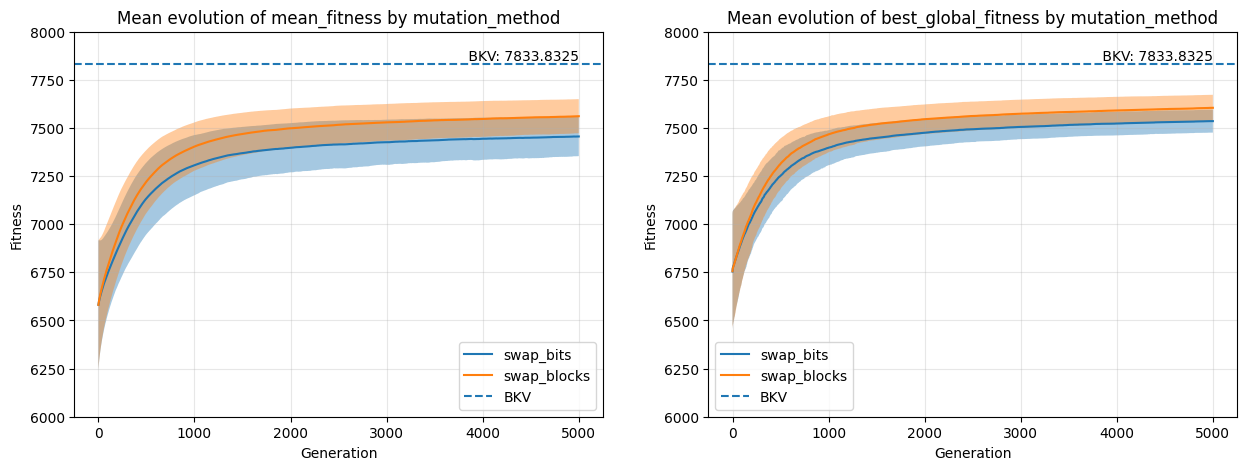

In [21]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plot_mean_fitness_evolution_by(
    results_df,
    group_by="mutation_method",
    history_key="mean_fitness",
    show_std=True,
    best_known_value = best_cost,
    best_known_label = "BKV"
)
plt.ylim(6000, 8000)

plt.subplot(1,2,2)
plot_mean_fitness_evolution_by(
    results_df,
    group_by="mutation_method",
    history_key="best_global_fitness",
    show_std=True,
    best_known_value = best_cost,
    best_known_label = "BKV"
)
plt.ylim(6000, 8000)


# Pruebas reinicialización

In [ ]:
init_methods = ["randomized_greedy"]

parent_selection_methods = [
    {"method": "greedy", "kwargs": {}},
    {"method": "sa", "kwargs": {"temperature": 1.0}},
]

crossover_methods = [
    "sum_repair",
    "swap_differences",
]

mutation_methods = [
    "swap_bits",
    "swap_blocks",
]

substitution_methods = [
    "worst",
]
restart_methods = [
    None,
    "random", 
    "fitness_weighted"
]

# id_caso = 0
for id_caso in range(10):#len(excel_pruebas)
    caso = excel_pruebas.case[id_caso]
    print("Caso a analizar:",caso)

    D, N, m = load_mdp_instance(f"./data/{caso}.txt")
    best_cost = excel_pruebas.bestCost[id_caso]
    rng = np.random.default_rng(42)
    try:
        results_df = coarse_grid_search_mdp(
            D=D,
            N=N,
            m=m,
            k_runs=5,
            num_generations=2500,
            population_size=250,
            init_methods=init_methods,
            parent_selection_methods=parent_selection_methods,
            crossover_methods=crossover_methods,
            mutation_methods=mutation_methods,
            substitution_methods=substitution_methods,
            p_s=10.0,
            p_p=5.0,
            p_c=50.0,
            n_steps=4,
            print_every=None,
            base_seed=1000,
            restart_methods=restart_methods,
            restart_percent = 99,
            restart_every = 250
        )
        results_df.to_csv(f"{caso}_results_df_withRestart.csv", index=False)
    except:
        print("Error, continuando con siguiente caso")

Caso a analizar: MDG-a_1_n500_m50
Total configurations: 24
Total simulations: 120


Error, continuando con siguiente caso
Caso a analizar: MDG-a_2_n500_m50
Total configurations: 24
Total simulations: 120


Error, continuando con siguiente caso
Caso a analizar: MDG-a_3_n500_m50
Total configurations: 24
Total simulations: 120


Error, continuando con siguiente caso
Caso a analizar: MDG-a_4_n500_m50
Total configurations: 24
Total simulations: 120


Running GridSearch configs:  17%|█▋        | 4/24 [03:02<15:06, 45.32s/it]

In [ ]:
init_methods = ["randomized_greedy"]

parent_selection_methods = [
    {"method": "greedy", "kwargs": {}},
    #{"method": "sa", "kwargs": {"temperature": 1.0}},
]

crossover_methods = [
    #"sum_repair",
    "swap_differences",
]

mutation_methods = [
    #"swap_bits",
    "swap_blocks",
]

substitution_methods = [
    #"random",
    "worst",
]
restart_methods = [
    None,
    "random", 
    #"fitness_weighted"
]

# id_caso = 0
for id_caso in range(1):#len(excel_pruebas)
    caso = excel_pruebas.case[id_caso]
    print("Caso a analizar:",caso)

    D, N, m = load_mdp_instance(f"./data/{caso}.txt")
    best_cost = excel_pruebas.bestCost[id_caso]
    rng = np.random.default_rng(42)
    # try:
    results_df = coarse_grid_search_mdp(
        D=D,
        N=N,
        m=m,
        k_runs=5,
        num_generations=20000,
        population_size=250,
        init_methods=init_methods,
        parent_selection_methods=parent_selection_methods,
        crossover_methods=crossover_methods,
        mutation_methods=mutation_methods,
        substitution_methods=substitution_methods,
        p_s=20.0,
        p_p=10.0,
        p_c=50.0,
        n_steps=3,
        print_every=None,
        base_seed=1000,
        restart_methods=restart_methods,
        restart_percent = 80,
        restart_every = 250
    )
    results_df.to_csv(f"{caso}_results_df_withRestart.csv", index=False)
    # except:
    #     print("Error, continuando con siguiente caso")

Caso a analizar: MDG-a_1_n500_m50
Total configurations: 2
Total simulations: 10


In [57]:
init_methods = ["randomized_greedy"]

parent_selection_methods = [
    {"method": "greedy", "kwargs": {}},
    #{"method": "sa", "kwargs": {"temperature": 1.0}},
]

crossover_methods = [
    #"sum_repair",
    "swap_differences",
]

mutation_methods = [
    #"swap_bits",
    "swap_blocks",
]

substitution_methods = [
    #"random",
    "worst",
]
restart_methods = [
    None,
    "random", 
    "fitness_weighted"
]

# id_caso = 0
for id_caso in range(1):#len(excel_pruebas)
    caso = excel_pruebas.case[id_caso]
    print("Caso a analizar:",caso)

    D, N, m = load_mdp_instance(f"./data/{caso}.txt")
    best_cost = excel_pruebas.bestCost[id_caso]
    rng = np.random.default_rng(42)
    # try:
    results_df = coarse_grid_search_mdp(
        D=D,
        N=N,
        m=m,
        k_runs=5,
        num_generations=20000,
        population_size=250,
        init_methods=init_methods,
        parent_selection_methods=parent_selection_methods,
        crossover_methods=crossover_methods,
        mutation_methods=mutation_methods,
        substitution_methods=substitution_methods,
        p_s=15.0,
        p_p=5.0,
        p_c=50.0,
        n_steps=3,
        print_every=None,
        base_seed=1000,
        restart_methods=restart_methods,
        restart_percent = 80,
        restart_every = 250,
        unique_offspring_list=[False, True]
    )
    results_df.to_csv(f"{caso}_results_df_withRestart_withUO.csv", index=False)
    # except:
    #     print("Error, continuando con siguiente caso")

Caso a analizar: MDG-a_1_n500_m50
Total configurations: 6
Total simulations: 30


In [19]:
init_methods = ["randomized_greedy"]

parent_selection_methods = [
    {"method": "greedy", "kwargs": {}},
]

crossover_methods = [
    "swap_differences",
]

mutation_methods = [
    "swap_blocks",
]

substitution_methods = [
    "worst",
]
restart_methods = [
    None,
    "random", 
    "fitness_weighted"
]

# id_caso = 0
for id_caso in range(1):#len(excel_pruebas)
    caso = excel_pruebas.case[id_caso]
    print("Caso a analizar:",caso)

    D, N, m = load_mdp_instance(f"./data/{caso}.txt")
    best_cost = excel_pruebas.bestCost[id_caso]
    rng = np.random.default_rng(42)
    # try:
    results_df = coarse_grid_search_mdp(
        D=D,
        N=N,
        m=m,
        k_runs=5,
        num_generations=30000,
        population_size=250,
        init_methods=init_methods,
        parent_selection_methods=parent_selection_methods,
        crossover_methods=crossover_methods,
        mutation_methods=mutation_methods,
        substitution_methods=substitution_methods,
        p_s=15.0,
        p_p=5.0,
        p_c=50.0,
        n_steps=3,
        print_every=None,
        base_seed=1000,
        restart_methods=restart_methods,
        restart_percent = 80,
        restart_every = 250,
        unique_offspring_list=[False, True]
    )
    results_df.to_csv(f"{caso}_results_df_withRestart_withUO_30000its.csv", index=False)
    # except:
    #     print("Error, continuando con siguiente caso")

Caso a analizar: MDG-a_1_n500_m50
Total configurations: 6
Total simulations: 30


# Pruebas sobre todos los ficheros

In [20]:
init_methods = ["randomized_greedy"]

parent_selection_methods = [
    {"method": "greedy", "kwargs": {}},
]

crossover_methods = [{"swap_differences":0.8, "sum_repair":0.2}]

mutation_methods = [{"swap_blocks":0.8, "swap_bits":0.2}]

substitution_methods = ["worst"]

restart_methods = [None]

unique_offspring_list=[True]

# id_caso = 0
for id_caso in range(len(excel_pruebas)):
    caso = excel_pruebas.case[id_caso]
    print("Caso a analizar:",caso)

    D, N, m = load_mdp_instance(f"./data/{caso}.txt")
    best_cost = excel_pruebas.bestCost[id_caso]
    rng = np.random.default_rng(42)
    try:
        results_df = coarse_grid_search_mdp_probs(
            D=D,
            N=N,
            m=m,
            k_runs=10,
            num_generations=3000,
            population_size=250,
            init_methods=init_methods,
            parent_selection_methods=parent_selection_methods,
            crossover_dists=crossover_methods,
            mutation_dists=mutation_methods,
            substitution_methods=substitution_methods,
            p_s=15.0,
            p_p=5.0,
            p_c=50.0,
            n_steps=4,
            print_every=None,
            base_seed=1000,
            restart_methods=restart_methods,
            unique_offspring_list=unique_offspring_list
        )
        results_df.to_csv(f"{caso}_results_df_withUO.csv", index=False)
    except:
        print("*"*30,"\n","ERROR, continuando con siguiente caso\n","*"*30,"\n",)

Caso a analizar: MDG-a_1_n500_m50
Total configurations: 1
Total simulations: 10


Caso a analizar: MDG-a_2_n500_m50
Total configurations: 1
Total simulations: 10


Caso a analizar: MDG-a_3_n500_m50
Total configurations: 1
Total simulations: 10


Caso a analizar: MDG-a_4_n500_m50
Total configurations: 1
Total simulations: 10


Caso a analizar: MDG-a_5_n500_m50
Total configurations: 1
Total simulations: 10


...

Caso a analizar: MDG-c_13_n3000_m500
Total configurations: 1
Total simulations: 10


Caso a analizar: MDG-c_14_n3000_m500
Total configurations: 1
Total simulations: 10


Caso a analizar: MDG-c_15_n3000_m500
Total configurations: 1
Total simulations: 10


Caso a analizar: MDG-c_19_n3000_m600
Total configurations: 1
Total simulations: 10


Caso a analizar: MDG-c_20_n3000_m600
Total configurations: 1
Total simulations: 10


# Pruebas

In [22]:
id_caso = 10
caso = excel_pruebas.case[id_caso]
print("Caso a analizar:",caso)
D, N, m = load_mdp_instance(f"./data/{caso}.txt")
best_cost = excel_pruebas.bestCost[id_caso]
rng = np.random.default_rng(42)

res = {
    "random" : {
        "best_solution" : None, 
        "best_fitness" : None, 
        "population" : None, 
        "fitness" : None, 
        "history" : None, 
        "config" : None
    }, 

    "greedy" : {
        "best_solution" : None, 
        "best_fitness" : None, 
        "population" : None, 
        "fitness" : None, 
        "history" : None, 
        "config" : None
    }, 

    "randomized_greedy": {
        "best_solution" : None, 
        "best_fitness" : None, 
        "population" : None, 
        "fitness" : None, 
        "history" : None, 
        "config" : None
    }
}

for init_method in res.keys():
    sol = test_genetic_mdp(
        D,
        N,
        m,
        num_generations= 5000,
        population_size=400,
        init_method=init_method,
        p_s=10,
        p_p=5,
        p_c=75,
        substitution="random",
        crossover_operators= {"sum_repair": 1.0},
        mutation_operators = {"swap_bits": 0.5, "swap_blocks": 0.5},
        print_every=100,
        rng= rng,
        n_steps = 4
    )
    for i, key in enumerate(res[init_method].keys()):
        res[init_method].update({key : sol[i]})

Caso a analizar: MDG-b_21_n2000_m200
Generation 0 | Initial best = 10056662.0630 | Best in population = 10056662.0630 | Current global best = 10056662.0630 | Mean fitness = 9949958.5383
Generation 100 | Initial best = 10056662.0630 | Best in population = 10102528.3401 | Current global best = 10124512.4559 | Mean fitness = 10005070.3094
Generation 200 | Initial best = 10056662.0630 | Best in population = 10134117.2988 | Current global best = 10134117.2988 | Mean fitness = 10034086.5825
Generation 300 | Initial best = 10056662.0630 | Best in population = 10157680.4550 | Current global best = 10157680.4550 | Mean fitness = 10071709.3220
Generation 400 | Initial best = 10056662.0630 | Best in population = 10203838.4308 | Current global best = 10243719.2170 | Mean fitness = 10106332.2148
Generation 500 | Initial best = 10056662.0630 | Best in population = 10231262.4068 | Current global best = 10256512.8874 | Mean fitness = 10149811.6845
Generation 600 | Initial best = 10056662.0630 | Best i

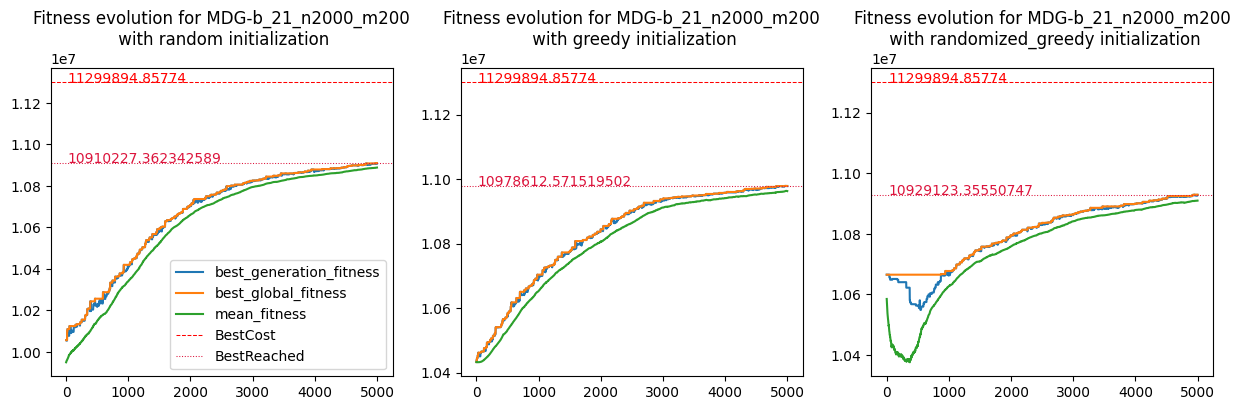

In [23]:
plt.figure(figsize=(15,4))
for col_i, init_method in enumerate(res.keys()):
    plt.subplot(1,3,col_i+1)
    for key in list(res[init_method]["history"].keys())[1:]:
        plt.plot(res[init_method]["history"]["generation"], res[init_method]["history"][key], label = key)

    plt.axhline(y=best_cost, label="BestCost", ls="--", lw=0.75, color="red")
    plt.text(s=best_cost, x= 20, y = best_cost+10 , color="red")

    plt.axhline(y=res[init_method]["best_fitness"], label="BestReached", ls=":", lw=0.75, color="crimson")
    plt.text(s=res[init_method]["best_fitness"], x= 20, y = res[init_method]["best_fitness"]+10 , color="crimson")

    plt.title(f"Fitness evolution for {caso}\n with {init_method} initialization")
    if col_i == 0:
        plt.legend()
    # plt.ylim(6000, 8000)
plt.show()